<a href="https://colab.research.google.com/github/OlaniyiSegunIsrael/Assignment-9-SO/blob/main/Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Assignment 9: Unsupervised Learning

- GitHub link:https://github.com/OlaniyiSegunIsrael/Assignment-9-SO
- Google colab link: https://colab.research.google.com/drive/1baQ13iTzj2fDIwsnLL-jwcOkYr5FzDfL?usp=sharing

In [23]:
!apt-get install -y git
!git config --global user.email "segun.olaniyi@students.williscollege.com"
!git config --global user.name "OlaniyiSegunIsrael"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [24]:
!git clone https://github.com/OlaniyiSegunIsrael/Assignment-9-SO.git
%cd Assignment-9-SO
!ls

Cloning into 'Assignment-9-SO'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Assignment-9-SO
README.md


In [25]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
#Load Dataset
# Load dataset
data = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column (house price)
df['Price'] = data.target

# View data
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [3]:
#Preprocessing
print(df.isnull().sum())

# Fill missing values if any
df = df.fillna(df.mean())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


In [4]:
#Feature Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

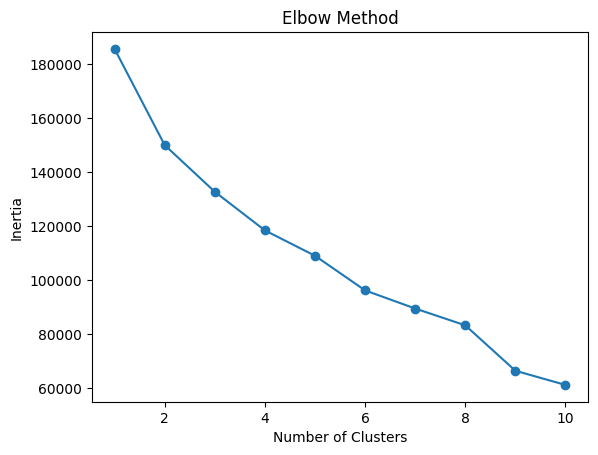

In [5]:
#K-Means Clustering
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [6]:
#Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

df['KMeans_Cluster'] = kmeans_labels

In [7]:
#Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
hier_labels = hierarchical.fit_predict(scaled_data)

df['Hierarchical_Cluster'] = hier_labels

In [8]:
#Dimensionality Reduction (PCA)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Convert to DataFrame
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

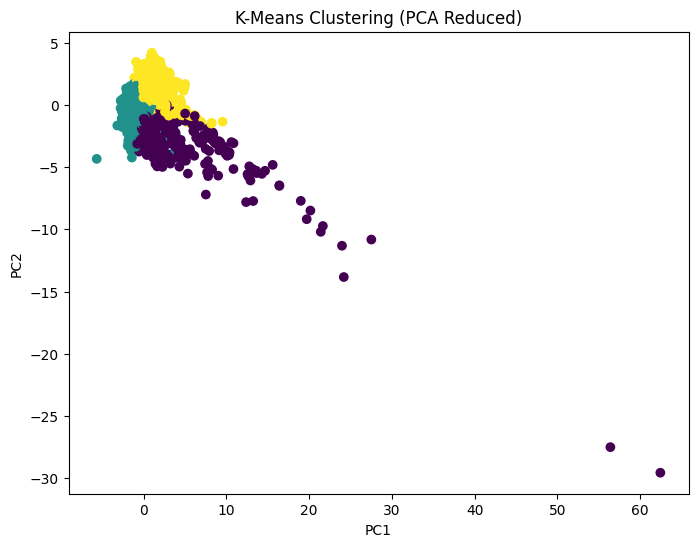

In [22]:
#Visualization of Clusters
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=kmeans_labels)
plt.title("K-Means Clustering (PCA Reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


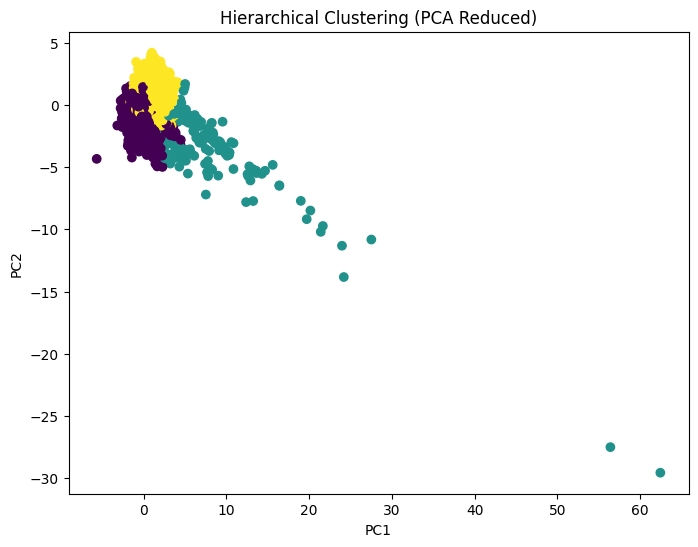

In [14]:
#Hierarchical Clusters
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=hier_labels)
plt.title("Hierarchical Clustering (PCA Reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [11]:
#Model Evaluation
kmeans_score = silhouette_score(scaled_data, kmeans_labels)
hier_score = silhouette_score(scaled_data, hier_labels)

print("K-Means Silhouette Score:", kmeans_score)
print("Hierarchical Silhouette Score:", hier_score)

K-Means Silhouette Score: 0.28510475363570564
Hierarchical Silhouette Score: 0.27569444688241224


In [12]:
#Simple Interpretation Output
print(df.groupby('KMeans_Cluster').mean())

                  MedInc   HouseAge  AveRooms  AveBedrms   Population  \
KMeans_Cluster                                                          
0               6.885622  27.651443  7.414963   1.203391  1241.645734   
1               3.309527  28.670126  4.873744   1.069881  1592.894689   
2               3.349556  29.006920  5.323935   1.087126  1286.324847   

                AveOccup   Latitude   Longitude     Price  \
KMeans_Cluster                                              
0               2.735894  35.127891 -119.427073  3.946473   
1               3.301657  33.947009 -117.970101  1.758657   
2               2.912046  38.001329 -121.681028  1.693136   

                Hierarchical_Cluster  
KMeans_Cluster                        
0                           0.590866  
1                           0.142857  
2                           1.965792  


In [19]:
#Deployment & Monitoring (Concept in Code Comments)
# Example pseudo-deployment steps:

import joblib

# 1. Save model and scaler
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

# 2. Load model and scaler later
model = joblib.load("kmeans_model.pkl")
scaler = joblib.load("scaler.pkl")

# 3. Predict new data

# Example: new housing data (must match original feature columns)
new_data = pd.DataFrame({
    'MedInc': [5.0],
    'HouseAge': [20],
    'AveRooms': [6],
    'AveBedrms': [1],
    'Population': [1000],
    'AveOccup': [3],
    'Latitude': [34.0],
    'Longitude': [-118.0],
    'Price': [2.5]  })

# Scale new data using same scaler
new_data_scaled = scaler.transform(new_data)

# Make prediction (cluster assignment)
prediction = model.predict(new_data_scaled)

print("Cluster assigned:", prediction[0])

Cluster assigned: 1
